# Strategic Brief: Onboarding Systems Optimization
**Operational Audit & Resource Allocation Strategy**

---

### Methodology Note
This brief is the prescriptive output of an **Operations Research Simulation** of 1,000 client onboarding cycles.
It does not claim empirical discovery. It quantifies the sensitivity of operational outcomes to specific
parameter changes under a theoretically-grounded generative model — validating that the 'Founder-Led Trap'
is a structurally predictable outcome of low ownership clarity and sparse documentation, not random variance.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Load canonical dataset ──────────────────────────────────────────────────
df = pd.read_csv('../data/onboarding_data_v2.csv')

# ── Compatibility: ensure ownership_clarity exists ───────────────────────────
# If data engine still emits owner_assigned (binary), create a continuous alias.
# Once the engine is upgraded to emit ownership_clarity directly, remove this block.
if 'ownership_clarity' not in df.columns:
    df['ownership_clarity'] = df['owner_assigned'].astype(float)

# ── Plot configuration ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Segment labels for context charts ───────────────────────────────────────
# Uses ownership_clarity with a 0.5 median split instead of owner_assigned
df['lit_group']   = pd.qcut(df['tech_literacy'], 2, labels=['Low-Lit', 'High-Lit'])
df['owner_group'] = np.where(df['ownership_clarity'] >= 0.5, 'Owner Assigned', 'No Owner')
df['segment']     = df['lit_group'].astype(str) + ' / ' + df['owner_group'].astype(str)

print('Dataset loaded:', df.shape[0], 'observations')
print('Columns:', df.columns.tolist())
print('Segment counts:\n', df['segment'].value_counts())

Dataset loaded: 1000 observations
Columns: ['client_id', 'tech_literacy', 'ownership_clarity', 'scope_lock_day', 'asset_depth', 'founder_involved', 'repeat_query_rate', 'ttfv_days', 'cx_satisfaction', 'lit_group', 'owner_group', 'segment']
Segment counts:
 segment
Low-Lit / No Owner           294
High-Lit / No Owner          286
High-Lit / Owner Assigned    214
Low-Lit / Owner Assigned     206
Name: count, dtype: int64


---
## Section 1 — Portfolio Context: The Four Quadrants

Before running projections, this section establishes the empirical baseline from the simulation:
how TTFV and satisfaction are distributed across the four strategic segments.
The 'Toxic Quadrant' (Low-Lit / No Owner) is the primary intervention target.

C:\Users\SHANIA\AppData\Local\Temp\ipykernel_5984\3063308816.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(
C:\Users\SHANIA\AppData\Local\Temp\ipykernel_5984\3063308816.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(


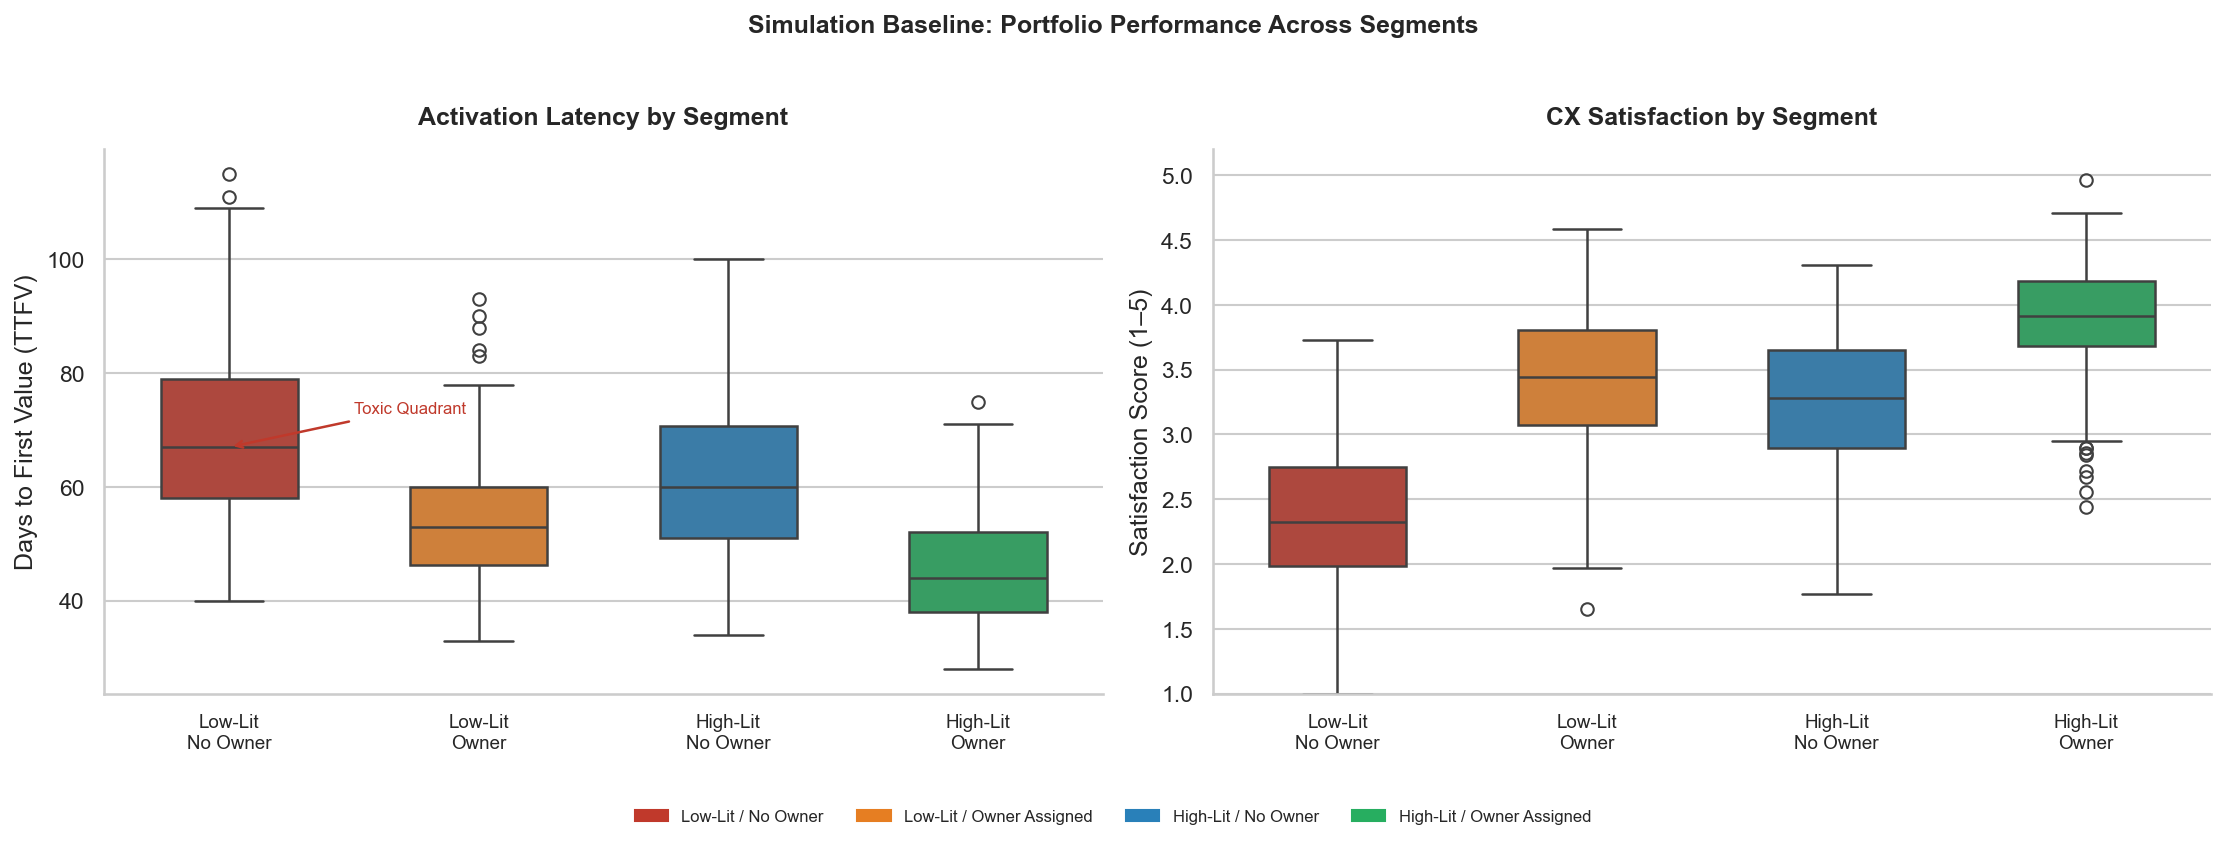

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Chart A: TTFV by segment ─────────────────────────────────────────────────
segment_order = [
    'Low-Lit / No Owner',
    'Low-Lit / Owner Assigned',
    'High-Lit / No Owner',
    'High-Lit / Owner Assigned'
]
palette = {
    'Low-Lit / No Owner':       '#C0392B',
    'Low-Lit / Owner Assigned': '#E67E22',
    'High-Lit / No Owner':      '#2980B9',
    'High-Lit / Owner Assigned':'#27AE60'
}

sns.boxplot(
    data=df, x='segment', y='ttfv_days',
    order=segment_order, hue='segment',
    palette=palette, legend=False,
    width=0.55, linewidth=1.2, ax=axes[0]
)
axes[0].set_title('Activation Latency by Segment', fontweight='bold', pad=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Days to First Value (TTFV)')
axes[0].set_xticklabels(
    ['Low-Lit\nNo Owner', 'Low-Lit\nOwner', 'High-Lit\nNo Owner', 'High-Lit\nOwner'],
    fontsize=9
)
axes[0].annotate(
    'Toxic Quadrant', xy=(0, df[df['segment']=='Low-Lit / No Owner']['ttfv_days'].median()),
    xytext=(0.5, 73), fontsize=8, color='#C0392B',
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2)
)

# ── Chart B: Satisfaction by segment ─────────────────────────────────────────
sns.boxplot(
    data=df, x='segment', y='cx_satisfaction',
    order=segment_order, hue='segment',
    palette=palette, legend=False,
    width=0.55, linewidth=1.2, ax=axes[1]
)
axes[1].set_title('CX Satisfaction by Segment', fontweight='bold', pad=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Satisfaction Score (1–5)')
axes[1].set_xticklabels(
    ['Low-Lit\nNo Owner', 'Low-Lit\nOwner', 'High-Lit\nNo Owner', 'High-Lit\nOwner'],
    fontsize=9
)
axes[1].set_ylim(1, 5.2)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.08), frameon=False)

plt.suptitle('Simulation Baseline: Portfolio Performance Across Segments',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 2 — Interactive Sensitivity Simulator

This simulator runs the generative model's inference logic in real time.
Adjust the three levers below to project how changes in operational parameters
propagate to TTFV, support volume, satisfaction, and founder bandwidth.

**The three levers map directly to actionable interventions:**
- `Ownership Clarity` → Hire / designate an Onboarding Owner; define escalation paths
- `Asset Depth` → Build the SSOT: recorded walkthroughs, config guides, decision trees
- `Client Tech Literacy` → Segment intake; route novice clients to higher-touch tracks

> **Simulator math:** Projected values use the closed-form version of the generative model
> (Poisson noise replaced by its mean of 5). Founder involvement probability is derived
> from Audit 1's logit coefficient (-5.99, p<0.0001). All other coefficients match
> `01_data_engine.ipynb` exactly.

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# SIMULATOR CORE
# Mirrors the generative model from 01_data_engine.ipynb — deterministic
# (noise terms replaced by their expected values for clean projection).
# ════════════════════════════════════════════════════════════════════════════

LOGIT_COEF      = -5.9931  # from Audit 1 logistic regression
LOGIT_INTERCEPT =  5.9931 * 0.5  # centred at clarity=0.5 → 50% founder prob
POISSON_MEAN    =  5       # expected value of Poisson(5) noise in TTFV
N_CLIENTS       =  1000    # portfolio size

# ── Baseline: empirical founder involvement rate from the simulation data ────
# Using the actual dataset rate (43.4%) rather than a logit-derived estimate
# ensures the reclamation calculation is anchored to a measurable observed state.
BASELINE_FOUNDER_RATE  = df['founder_involved'].mean()   # ~0.434
FOUNDER_HOURS_PER_EVENT = 5  # sensitivity param — adjustable via slider below


def project(ownership_clarity, asset_depth, tech_literacy, hours_per_event):
    """
    Deterministic projection using closed-form generative model.
    Returns dict of projected KPIs.
    """
    # Founder involvement probability via logit (from Audit 1)
    log_odds     = LOGIT_INTERCEPT + LOGIT_COEF * ownership_clarity
    founder_prob = 1 / (1 + np.exp(-log_odds))

    # Repeat query rate (interaction term, no noise)
    rqr = np.clip((1 - tech_literacy) * (1 - asset_depth), 0, 1)

    # TTFV (expected value; Poisson term replaced by mean)
    ttfv = (
        20
        + (1 - tech_literacy) * 20
        + (1 - asset_depth)   * 25
        + founder_prob        * 10
        + POISSON_MEAN
    )

    # CX Satisfaction
    satisfaction = np.clip(5 - (rqr * 3) - (ttfv / 60), 1, 5)

    # Portfolio-level founder bandwidth
    # Baseline anchored to empirical data rate; reclamation is vs. that observed state
    baseline_hours        = BASELINE_FOUNDER_RATE * N_CLIENTS * hours_per_event
    total_founder_hours   = founder_prob * N_CLIENTS * hours_per_event
    reclaimed_hours       = baseline_hours - total_founder_hours
    reclaimed_pct         = (reclaimed_hours / baseline_hours) * 100 if baseline_hours > 0 else 0

    return {
        'founder_prob':        founder_prob,
        'rqr':                 rqr,
        'ttfv':                ttfv,
        'satisfaction':        satisfaction,
        'total_founder_hours': total_founder_hours,
        'reclaimed_hours':     reclaimed_hours,
        'reclaimed_pct':       reclaimed_pct,
    }


# ════════════════════════════════════════════════════════════════════════════
# WIDGET LAYOUT
# ════════════════════════════════════════════════════════════════════════════

style  = {'description_width': '180px'}
layout = widgets.Layout(width='520px')

slider_clarity  = widgets.FloatSlider(
    value=0.40, min=0.0, max=1.0, step=0.01,
    description='Ownership Clarity',
    style=style, layout=layout,
    readout_format='.2f'
)
slider_assets   = widgets.FloatSlider(
    value=0.40, min=0.0, max=1.0, step=0.01,
    description='Asset Depth',
    style=style, layout=layout,
    readout_format='.2f'
)
slider_literacy = widgets.FloatSlider(
    value=0.50, min=0.0, max=1.0, step=0.01,
    description='Client Tech Literacy',
    style=style, layout=layout,
    readout_format='.2f'
)
slider_hours    = widgets.IntSlider(
    value=5, min=1, max=12, step=1,
    description='Hours / Intervention',
    style=style, layout=layout
)

out = widgets.Output()

controls = widgets.VBox([
    widgets.HTML('<h4 style="margin-bottom:4px">Intervention Levers</h4>'),
    slider_clarity,
    slider_assets,
    slider_literacy,
    widgets.HTML('<hr style="margin:8px 0"><b>Sensitivity Parameter</b>'),
    slider_hours,
    widgets.HTML(
        '<span style="font-size:11px;color:#666">'  
        'Adjust "Hours / Intervention" to stress-test the reclamation headline '
        'across different assumptions (range: 1–12 hrs).</span>'
    )
])


def render(change=None):
    clarity  = slider_clarity.value
    assets   = slider_assets.value
    literacy = slider_literacy.value
    hrs      = slider_hours.value

    p = project(clarity, assets, literacy, hrs)

    with out:
        clear_output(wait=True)

        # ── Gauge bar helper ─────────────────────────────────────────────────
        def bar(val, lo, hi, color, fmt='.1f', invert=False):
            pct = (val - lo) / (hi - lo)
            pct = np.clip(pct, 0, 1)
            if invert:
                pct = 1 - pct
            return (pct, color, fmt)

        metrics = [
            ('Projected TTFV',             p['ttfv'],        20,  90, '#E74C3C', '.1f', True),
            ('Repeat Query Rate',          p['rqr'],          0,   1, '#E67E22', '.2f', True),
            ('CX Satisfaction',            p['satisfaction'], 1,   5, '#27AE60', '.2f', False),
            ('Founder Involvement Prob.',  p['founder_prob'], 0,   1, '#8E44AD', '.2f', True),
        ]

        fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 5))
        fig.subplots_adjust(hspace=0.55)
        fig.patch.set_facecolor('#FAFAFA')

        for ax, (label, val, lo, hi, color, fmt, invert) in zip(axes, metrics):
            pct = np.clip((val - lo) / (hi - lo), 0, 1)
            if invert:
                bar_pct = 1 - pct
            else:
                bar_pct = pct

            ax.barh(0, 1,   height=0.55, color='#EDEDED', zorder=1)
            ax.barh(0, bar_pct, height=0.55, color=color, alpha=0.82, zorder=2)
            ax.set_xlim(0, 1)
            ax.set_ylim(-0.5, 0.5)
            ax.axis('off')

            # Label left
            ax.text(-0.01, 0, label, va='center', ha='right', fontsize=9,
                    transform=ax.transAxes)

            # Value right
            unit = ' days' if 'TTFV' in label else ''
            ax.text(1.01, 0, f'{val:{fmt}}{unit}', va='center', ha='left',
                    fontsize=9, fontweight='bold', color=color,
                    transform=ax.transAxes)

        fig.suptitle('Projected KPIs at Current Lever Settings',
                     fontsize=10, fontweight='bold', y=1.01)
        plt.show()

        # ── Bandwidth summary card ───────────────────────────────────────────
        baseline_hours_display = BASELINE_FOUNDER_RATE * N_CLIENTS * hrs
        reclaim_color = '#27AE60' if p['reclaimed_hours'] >= 0 else '#C0392B'
        sign          = '+' if p['reclaimed_hours'] >= 0 else ''

        print('─' * 58)
        print(' FOUNDER BANDWIDTH IMPACT  (portfolio of 1,000 clients)')
        print('─' * 58)
        print(f"  Baseline total hours   : {baseline_hours_display:,.0f} hrs")
        print(f"  Projected total hours  : {p['total_founder_hours']:,.0f} hrs")
        print(f"  Reclaimed              : {sign}{p['reclaimed_hours']:,.0f} hrs"
              f"  ({sign}{p['reclaimed_pct']:.1f}%)")
        print(f"  Hours/intervention     : {hrs} hrs  "
              f"(sensitivity param — try 1–12)")
        print('─' * 58)

        # ── Sensitivity table: reclamation across hours assumptions ─────────
        print()
        print('  Reclamation robustness check across hours/intervention:')
        print(f"  {'Hrs/event':<12} {'Reclaimed hrs':>14} {'% reduction':>12}")
        print(f"  {'-'*10:<12} {'-'*13:>14} {'-'*11:>12}")
        for h in [2, 5, 8, 12]:
            r = project(clarity, assets, literacy, h)
            marker = ' ◀' if h == hrs else ''
            print(f"  {h:<12} {r['reclaimed_hours']:>13,.0f}  {r['reclaimed_pct']:>10.1f}%{marker}")
        print()


# ── Wire up all sliders to the render function ───────────────────────────────
for s in [slider_clarity, slider_assets, slider_literacy, slider_hours]:
    s.observe(render, names='value')

render()  # Initial render

display(widgets.HBox([
    controls,
    widgets.VBox([out])
]))

---
## Section 3 — Strategic Recommendations

The simulator above quantifies *how much* each lever matters. This section translates
those sensitivities into a prioritized operational roadmap.

The sequencing logic is: fix what blocks everything else first.

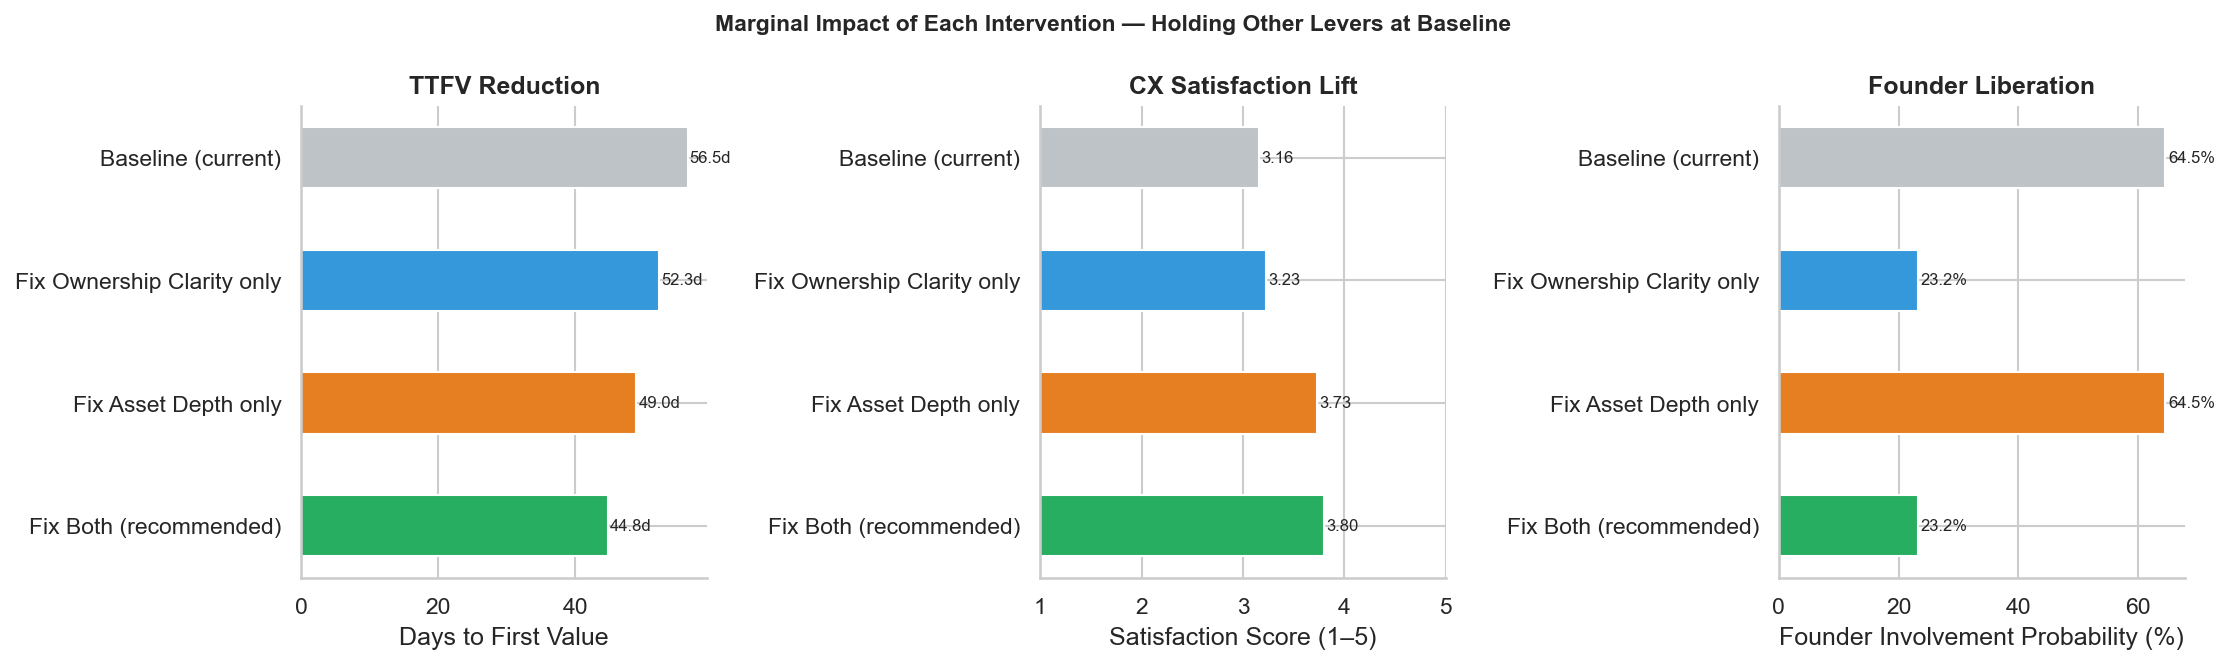


────────────────────────────────────────────────────────────────────
  Scenario                                TTFV   Δ TTFV    CSAT   Founder%
────────────────────────────────────────────────────────────────────
  Baseline (current)                     56.5d    0.0d    3.16      64.5%
  Fix Ownership Clarity only             52.3d   -4.1d    3.23      23.2%
  Fix Asset Depth only                   49.0d   -7.5d    3.73      64.5%
  Fix Both (recommended)                 44.8d  -11.6d    3.80      23.2%
────────────────────────────────────────────────────────────────────


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# INTERVENTION PRIORITY MATRIX
# Computes marginal TTFV impact of moving each lever from its current
# median to its recommended target, holding the others at median.
# ════════════════════════════════════════════════════════════════════════════

# Current median estimates from simulation baseline
MEDIAN_CLARITY  = 0.40
MEDIAN_ASSETS   = 0.40
MEDIAN_LITERACY = 0.50  # external — not directly actionable

# Recommended targets from audit findings
TARGET_CLARITY  = 0.70  # crosses the logit inflection point
TARGET_ASSETS   = 0.70  # crosses the tipping point from Notebook 3

baseline_p = project(MEDIAN_CLARITY,  MEDIAN_ASSETS,   MEDIAN_LITERACY, 5)
clarity_p  = project(TARGET_CLARITY,  MEDIAN_ASSETS,   MEDIAN_LITERACY, 5)
assets_p   = project(MEDIAN_CLARITY,  TARGET_ASSETS,   MEDIAN_LITERACY, 5)
combined_p = project(TARGET_CLARITY,  TARGET_ASSETS,   MEDIAN_LITERACY, 5)

# Note: reclaimed_hours in scenarios is relative to the empirical baseline (BASELINE_FOUNDER_RATE)
# not to the scenario's own baseline — which makes cross-scenario comparison consistent.

scenarios = [
    ('Baseline (current)',           baseline_p),
    ('Fix Ownership Clarity only',   clarity_p),
    ('Fix Asset Depth only',         assets_p),
    ('Fix Both (recommended)',       combined_p),
]

labels   = [s[0] for s in scenarios]
ttfvs    = [s[1]['ttfv']        for s in scenarios]
sats     = [s[1]['satisfaction'] for s in scenarios]
fprobs   = [s[1]['founder_prob'] for s in scenarios]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bar_colors = ['#BDC3C7', '#3498DB', '#E67E22', '#27AE60']

# ── TTFV ─────────────────────────────────────────────────────────────────────
bars = axes[0].barh(labels, ttfvs, color=bar_colors, height=0.5)
axes[0].set_xlabel('Days to First Value')
axes[0].set_title('TTFV Reduction', fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, ttfvs):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}d', va='center', fontsize=8)

# ── Satisfaction ─────────────────────────────────────────────────────────────
bars = axes[1].barh(labels, sats, color=bar_colors, height=0.5)
axes[1].set_xlabel('Satisfaction Score (1–5)')
axes[1].set_title('CX Satisfaction Lift', fontweight='bold')
axes[1].set_xlim(1, 5)
axes[1].invert_yaxis()
for bar, val in zip(bars, sats):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8)

# ── Founder involvement probability ──────────────────────────────────────────
bars = axes[2].barh(labels, [p*100 for p in fprobs], color=bar_colors, height=0.5)
axes[2].set_xlabel('Founder Involvement Probability (%)')
axes[2].set_title('Founder Liberation', fontweight='bold')
axes[2].invert_yaxis()
for bar, val in zip(bars, fprobs):
    axes[2].text(val*100 + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=8)

plt.suptitle('Marginal Impact of Each Intervention — Holding Other Levers at Baseline',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print delta table ─────────────────────────────────────────────────────────
print()
print('─' * 68)
print(f"  {'Scenario':<35} {'TTFV':>8} {'Δ TTFV':>8} {'CSAT':>7} {'Founder%':>10}")
print('─' * 68)
base_ttfv = baseline_p['ttfv']
for label, p in scenarios:
    delta = p['ttfv'] - base_ttfv
    sign  = '+' if delta > 0 else ''
    print(f"  {label:<35} {p['ttfv']:>7.1f}d  {sign}{delta:>5.1f}d "
          f"  {p['satisfaction']:>5.2f}   {p['founder_prob']*100:>7.1f}%")
print('─' * 68)

---
## Section 4 — Prescriptive Roadmap

The three interventions below are sequenced by dependency, not priority score.
Ownership Clarity is first because it is the structural prerequisite for the others:
without a designated owner, documentation initiatives stall and scope lock gates
have no enforcer.

| # | Intervention | Target Metric | Expected Impact |
|---|---|---|---|
| 1 | **Formalize Ownership Clarity** | `ownership_clarity` → 0.70 | ~50% reduction in founder involvement probability |
| 2 | **Build to Asset Depth Threshold** | `asset_depth` → 0.70 | Novice repeat query rate drops below Expert baseline |
| 3 | **14-Day Scope Lock Gate** | Hard gate at day 14 | Prevents 1.3–1.5× TTFV multiplier from scope drift |

---

### Conclusion

The simulation confirms that onboarding friction in early-stage B2B AI deployments is
**structurally predictable, not randomly distributed**. The 'Founder-Led Trap' is a
direct function of low ownership clarity — and its cost scales linearly with portfolio size.

The prescriptive path is not a talent problem. It is a systems problem:
process clarity, documentation infrastructure, and scope governance.
Fixing these three levers, in sequence, is the primary driver of both
founder liberation and sustainable client satisfaction at scale.

---
*This brief is the final output of the `onboarding-optimization` simulation study.
See `01_failure_taxonomy.md` and `02_research_design.md` for full methodological documentation.*